# Problem 1

Activation of split proteins using bipartite ligands. Split proteins are used in chemical biology applications as well as for genome-wide screens [here](https://en.wikipedia.org/wiki/Protein-fragment_complementation_assay). The general idea is to fuse one portion of the split protein to a bait protein. Then, the other protein can be fused to the prey protein. If the bait and prey interact, the two portions of the split protein are at a high local proximity, leading to complementation. 


## Problem 1a. 

You use computational modeling to estimate that the distance do between the interface of the split protein and the interface of the bait protein is 4.5 nanometers. You are considering two linker lengths of unstructured amino acids – one 18 amino acids long, and one 50. Determine the effective concentration of the bait protein for these two linker lengths. Which linker should you choose? =


| Linker length (# amino acids)	| [A]eff [mM] |
|-------------------------------|-------------|
| 18	                        | $2.9 \times 10^{-3}$          |
| 50	                        | 1.00          |

- Please see derivation blow


$[A]_{eff} = \frac{K_d^AS}{K_u^A}$

$[A]_{eff} = 5.03L^{-3/2} e^{\frac{-6.58\times10^{-2}d_0^2}{L}} \left[ 1 - \frac{0.987}{L} + 0.139 (\frac{d_0^2}{L^2}) - 2.51\times10^{-3} (\frac{d_0^4}{L^3}) -0.15(\frac{d_0^2}{L^3}) + 0.0204(\frac{d_0^4}{L^4}) - 5.17\times10^{-4}(\frac{d_0^6}{L^5}) +3.14\times10^{-6}(\frac{d_0^8}{L^6})\right]$

### Case 1: L = 18, $d = 4.5nm$
$[A]_{eff} \approx 2.9 \times 10^{-3} mM$

### Case 2: L = 50, $d = 4.5nm$

$[A]_{eff} \approx 1.00 mM$

You should choose the 50 aa linker

## Problem 1b 

These constructs are typically expressed in yeast driven by strong promoters, such that you can estimate the concentration of each fusion protein to be approximately 3 $\mu M$. The split protein has an estimated dissociation constant of 400 $\mu M (K_D^A)$. For a bait and prey protein that has an estimated dissociation constant $(K_D^B)$ of 100 nM, determine 

- (i.) $(K_D^{AB})$
- (ii.) the concentration of the split protein bound at equilibrium. 
- (iii.) the concentration of the split protein bound at equilibrium if the bait and prey protein do not interact $(K_D^B >> 1 mM)$. 
- (iv.) use this information to calculate the signal to noise of the assay (the concentration of the split protein when $K_D^B=100 nM$ over the concentration of the split protein if the bait and prey protein do not interact). Use a linker length found from part a (either 18 or 50 amino acids long).

|Parameter|	Value |
|---------|-------|
|$K_D^AB [μM]$| 3nM|
|Concentration of split protein when $K_D^B=100 nM [μM]$|$3.9\times10^{-1}\ \mu M$|
|Concentration of split protein when $K_D^B≫1 mM [μM]$|$2.98\times10^{-3}\ \mu M$|
|Signal to noise|131|

- for derivations see below

(i)

Converting to consistent units (µM):
- $K_D^A = 400\ \mu M$
- $K_D^B = 0.1\ \mu M$  
- $[A]_{eff} \approx 100\ \mu M$

$K_D^{AB} = \frac{K_D^A \cdot K_D^B}{[A]_{eff}} = \frac{400 \times 0.1}{100} \approx 4 \times 10^{-1}\mu M \approx 40nM$

(ii)

$y = \frac{[p]}{[p] + K_D^{B}} = \frac{3}{3 + 0.1} = 0.967$

$[bound protein] = 0.967 \cdot 4 \times 10^{-1}\ \mu M \approx 3.9 \times 10^{-1}\ \mu M$

(iii)

$y = \frac{[p]}{[p] + K_D^{A}} = \frac{3}{3 + 400} = 7.4 \times 10^{-3}$

$[bound protein] = 7.4 \times 10^{-3} \cdot 4\times10^{-1}\ \mu M \approx 2.98\times10^{-3} \mu M$

(iv.)

$S/N = \frac{3.9 \times 10^{-1}\ \mu M}{2.98\times10^{-3}\ \mu M} \approx 131$

# Problem 2

Bivalent binding at cell surfaces. Antibody drug conjugates (ADCs) are a form of targeted immunotherapy. A small molecule drug is conjugated to an antibody. The antibody targets certain cell populations, and the drug can be activated locally, both destroying the target cell and minimizing off-target toxicity. Your objective as a biological engineer is to maximize the quantity of a drug to a targeted cell. 

Assume that the targeted cell has a radius typical of a mammalian cell in suspension, and that these cells express approximately 2,000 copies of the targeted receptor per cell. 

## Problem 2A
The bivalent antibody you initially use has a monovalent $K_d (K_{d1})$ of 1 nM with its targeted receptor. Determine its $K_{d2}$ (number/cell) for the targeted cell.


$K_{d,2​}=\frac{8 \cdot \pi \cdot r_{cell}^2 \cdot ​r_{IgG} \cdot ​N_A​​}{3} \cdot K_{d,1​}$

- $r_{cell​} = 7.5 \mu m$
- $r_{IgG}  = 12.5 nm$
- $K_{d,1} = ​1 nM$
- $N_A = ​6.022 × 10^{23} mol^{-1}$

$K_{d,2​}=\frac{8 \cdot \pi \cdot (7.5\times10^{-6})^2 \cdot ​(12.5\times10^{-9}) \cdot ​6.022\times10^{23}​}{3} \cdot 1\times10^-9$

$K_{d,2}​ \approx 3.54\times10^9 (\frac{\#/cell​}{M}) \cdot 1\times10^{-9}​(M)$

$ \approx 3.54 << 2,000 = [R]$


## Problem 2b

Plot the number of drugs per cell as a function of the concentration of the ADC. Assume that there is a stoichiometry of 3 drugs per antibody. Use an ADC concentration range of 50 pM to 5 $\mu M$. 

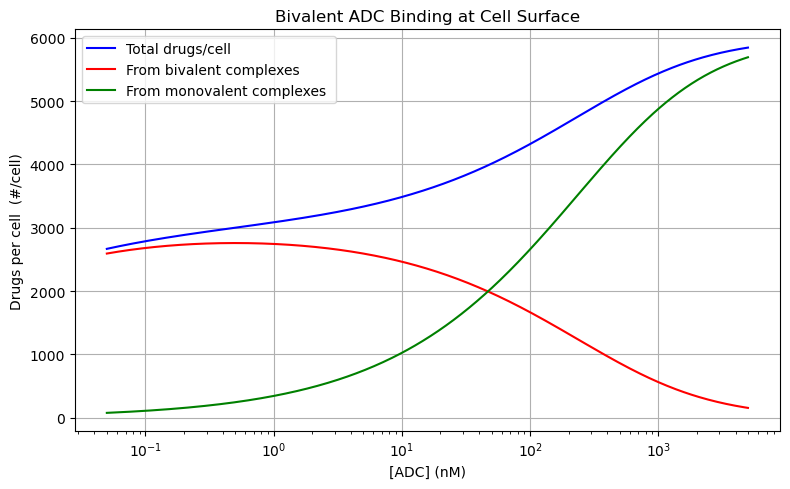

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Kd1    = 1e-9    # M  (monovalent Kd)
Kd2    = 3.54    # #/cell (from Problem 2A)
R0     = 2000    # #/cell (receptors per cell)
n_drug = 3       # drugs per antibody

# ADC concentration range: 50 pM to 5 uM
P0 = np.logspace(np.log10(50e-12), np.log10(5e-6), 500)  # mol/L

# Book equations 3.71-3.73:
#   C1    = R0 * beta * (-1 + sqrt(1 + 4*delta)) / (2*delta)       [eq 3.71]
#   C2    = (R0/2) * (1 + 2*delta - sqrt(1 + 4*delta)) / (2*delta) [eq 3.72]
#   R     = R0 - C1 - 2*C2                                         [eq 3.73]
#   beta  = P0 / (P0 + Kd1/2)                                      [eq 3.74]
#   delta = beta * (1 - beta) * R0 / Kd2                           [eq 3.75]

beta  = P0 / (P0 + Kd1/2)
delta = beta * (1 - beta) * R0 / Kd2

C1 = R0 * beta * (-1 + np.sqrt(1 + 4*delta)) / (2*delta)
C2 = (R0/2) * (1 + 2*delta - np.sqrt(1 + 4*delta)) / (2*delta)
R  = R0 - C1 - 2*C2

# Each antibody (C1 or C2) carries n_drug drugs
drugs_per_cell = (C1 + C2) * n_drug

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
P0_nM = P0 * 1e9

ax.plot(P0_nM, drugs_per_cell, color='blue',
        label='Total drugs/cell')
ax.plot(P0_nM, C2 * n_drug, color='red',
        label='From bivalent complexes')
ax.plot(P0_nM, C1 * n_drug, color='green',
        label='From monovalent complexes ')

ax.set_xscale('log')
ax.set_xlabel('[ADC] (nM)')
ax.set_ylabel('Drugs per cell  (#/cell)')
ax.set_title('Bivalent ADC Binding at Cell Surface')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Problem 2c
You should find that even at very high concentrations, you don’t get maximal drug delivery. This is undesirable since the upper limit of toxicity is 50 nM of the ADC. Determine whether it is possible to alter $K_{d1}$ for your drug such that you can allow 4,500 drugs to reach each cell at equilibrium, and at or under the toxicity limit. 

<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_37007/2754885310.py:77: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('Tunding $K_{d1}$ to 4,500 drugs/cell at$\leq$50 nM ADC?')
/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_37007/2754885310.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


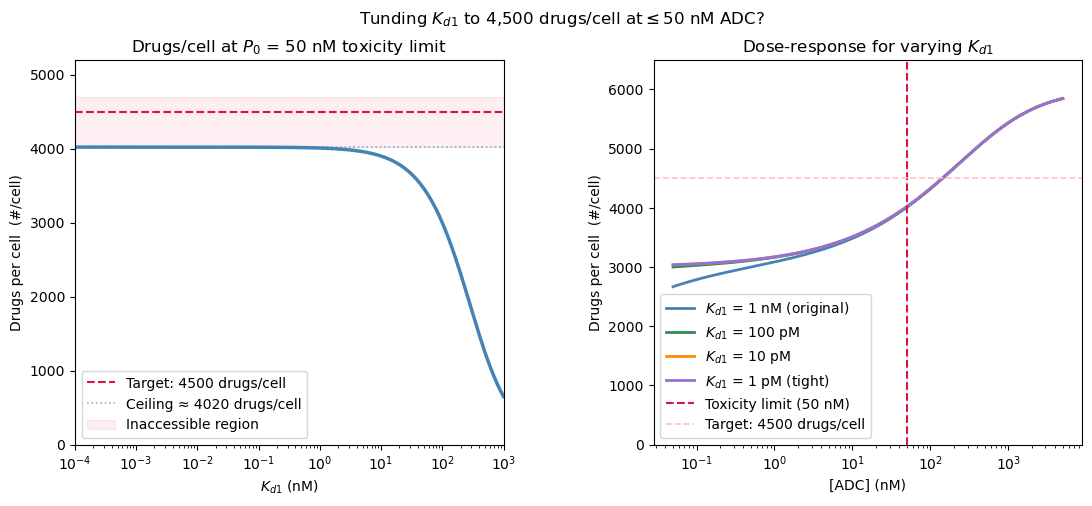

Not achievable: max drugs/cell at 50 nM = 4020, target = 4500 (12.0% above ceiling).


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Parameters
alpha  = 3.5e9   # Kd2 [#/cell] = alpha * Kd1 [M]  (from geometry in 2A)
R0     = 2000    # #/cell
n_drug = 3
P0_tox = 50e-9   # M  (toxicity limit)
target = 4500    # drugs/cell

def solve_bivalent(P0, Kd1):
    """Return (C1, C2, drugs/cell) using book eqs 3.71-3.73."""
    Kd2   = alpha * Kd1
    beta  = P0 / (P0 + Kd1/2)
    delta = beta * (1 - beta) * R0 / Kd2
    C1 = R0 * beta * (-1 + np.sqrt(1 + 4*delta)) / (2*delta)
    C2 = (R0/2) * (1 + 2*delta - np.sqrt(1 + 4*delta)) / (2*delta)
    return C1, C2, (C1 + C2) * n_drug

# Scan Kd1: drugs/cell at P0 = 50 nM
Kd1_arr = np.logspace(-13, -6, 600)   # 0.1 fM to 1 uM
drugs_vs_Kd1 = np.array([solve_bivalent(P0_tox, k)[2] for k in Kd1_arr])

ceiling = drugs_vs_Kd1.max()

# Full dose-response for several Kd1 values
P0_range = np.logspace(np.log10(50e-12), np.log10(5e-6), 500)

Kd1_cases = {
    '1 nM (original)': 1e-9,
    '100 pM':          1e-10,
    '10 pM':           1e-11,
    '1 pM (tight)':    1e-12,
}
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

# Figure
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)

# Left panel: drugs/cell vs Kd1 at 50 nM
ax1 = fig.add_subplot(gs[0])

ax1.semilogx(Kd1_arr * 1e9, drugs_vs_Kd1, color='steelblue', lw=2.5)
ax1.axhline(target,  color='crimson',   lw=1.5, ls='--', label=f'Target: {target} drugs/cell')
ax1.axhline(ceiling, color='steelblue', lw=1.2, ls=':',  alpha=0.6,
            label=f'Ceiling ≈ {ceiling:.0f} drugs/cell')
ax1.axhspan(ceiling, target + 200, color='crimson', alpha=0.07, label='Inaccessible region')

ax1.set_xlabel('$K_{d1}$ (nM)')
ax1.set_ylabel('Drugs per cell  (#/cell)')
ax1.set_title(f'Drugs/cell at $P_0$ = 50 nM toxicity limit')
ax1.set_ylim(0, 5200)
ax1.set_xlim(Kd1_arr[0]*1e9, Kd1_arr[-1]*1e9)
ax1.legend()
ax1.grid(False)

# Right panel: dose-response for each Kd1
ax2 = fig.add_subplot(gs[1])

for (label, Kd1), col in zip(Kd1_cases.items(), colors):
    drugs = np.array([solve_bivalent(p, Kd1)[2] for p in P0_range])
    ax2.plot(P0_range*1e9, drugs, color=col, lw=2, label=f'$K_{{d1}}$ = {label}')

ax2.axvline(50, color='crimson', lw=1.5, ls='--', label='Toxicity limit (50 nM)')
ax2.axhline(target, color='pink', lw=1.2, ls='--', label=f'Target: {target} drugs/cell')

ax2.set_xscale('log')
ax2.set_xlabel('[ADC] (nM)')
ax2.set_ylabel('Drugs per cell  (#/cell)')
ax2.set_title('Dose-response for varying $K_{d1}$')
ax2.set_ylim(0, 6500)
ax2.legend()
ax2.grid(False)

fig.suptitle('Tunding $K_{d1}$ to 4,500 drugs/cell at$\leq$50 nM ADC?')

plt.tight_layout()
plt.show()

print(f"Not achievable: max drugs/cell at 50 nM = {ceiling:.0f}, target = {target} ({(target/ceiling - 1)*100:.1f}% above ceiling).")

## Problem 2d

An alternative to ADC delivery by a standard IgG (bivalent) is conjugation to an antibody that binds monovalently. Determine the needed dissociation constant for a monovalent antibody to deliver 4,500 drugs per cell at the upper limit of toxicity of 50 nM.

In [45]:
# Parameters 
R0       = 2000    # receptors/cell
n_drug   = 3       # drugs per antibody
P0_tox   = 50e-9   # M, toxicity limit
target   = 4500    # drugs/cell

C_target = target / n_drug                       # 1500 #/cell
Kd_needed = R0 * P0_tox / C_target - P0_tox      # M

print(f"\n  Required Kd = {Kd_needed*1e9:.4f} nM")


  Required Kd = 16.6667 nM


## Problem 2e

Parts a-d are solutions for equilibrium binding relationships. However, the rate at which drugs accumulate on cell surfaces are also important for real-world efficacy. Plot the amount of drug per cell as a function of time for part b and your value of $K_d$ for the monovalent antibody in part d. Assume for both that $k_{on}$,1 is $1\times10^6 M^{-1}s^{-1}$. Initial conditions are no drug per cell, the antibody concentration is at the upper limit of toxicity (50 nM), and that the antibody amount is much greater than the amount of receptors.


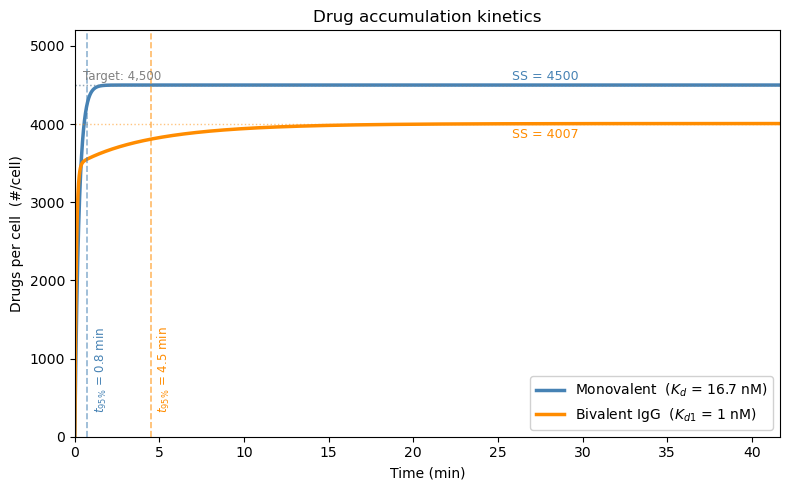

Monovalent (Kd = 16.67 nM):
koff  = 1.6667e-02 s-1
kobs  = kon*P0 + koff = 6.6667e-02 s-1
t_95% = 45.0 s  (0.75 min)
SS drugs/cell = 4500

Bivalent IgG (Kd1 = 1 nM, Kd2 = 3.5 #/cell):
koff1 = 1.0000e-03 s-1
koff2 = 1.0000e-03 s-1
kon2  = 2.8571e-04 (#/cell)-1 s-1
t_95% = 268.8 s  (4.48 min)
SS drugs/cell = 4007  (ceiling from 2C)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
R0 = 2000  
n_drug = 3     
P0 = 50e-9 
kon1 = 1e6   

# Bivalent (from 2B): Kd1 = 1 nM, Kd2 = 3.5 #/cell
Kd1 = 1e-9          
koff1 = Kd1 * kon1    
Kd2 = 3.5e9 * Kd1   
koff2 = koff1         
kon2 = koff2 / Kd2   

# Monovalent (from 2D): Kd = 50/3 nM to hit 4500 drugs/cell at 50 nM
Kd_mono = 50e-9 / 3      
koff_mono = Kd_mono * kon1 
kobs_mono = kon1 * P0 + koff_mono 

# Time array
t_max = 2500             
t_eval = np.linspace(0, t_max, 8000)
t_min = t_eval / 60        

# dC/dt = kon*P0*(R0 - C) - koff*C  =>  C(t) = C_ss * (1 - exp(-kobs*t))
C_ss_mono  = R0 * P0 / (Kd_mono + P0)
C_mono     = C_ss_mono * (1 - np.exp(-kobs_mono * t_eval))
drugs_mono = C_mono * n_drug

# --- Bivalent: numerical ODE ---
# State: y = [C1, C2]   (monovalently and bivalently bound antibodies, #/cell)
# R = R0 - C1 - 2*C2    (free receptors)
# dC1/dt = 2*kon1*P0*R - koff1*C1 - kon2*C1*R + 2*koff2*C2
# dC2/dt = kon2*C1*R   - 2*koff2*C2
def biv_odes(t, y):
    C1, C2 = y
    R = max(R0 - C1 - 2*C2, 0.0)
    dC1 = 2*kon1*P0*R - koff1*C1 - kon2*C1*R + 2*koff2*C2
    dC2 = kon2*C1*R   - 2*koff2*C2
    return [dC1, dC2]

sol    = solve_ivp(biv_odes, [0, t_max], [0, 0],
                   t_eval=t_eval, method='Radau', rtol=1e-9, atol=1e-12)
C1_biv = sol.y[0]
C2_biv = sol.y[1]
drugs_biv = (C1_biv + C2_biv) * n_drug

# Steady-state and t_95% for each
ss_mono = drugs_mono[-1]
ss_biv  = drugs_biv[-1]
t95_mono = t_eval[np.argmax(drugs_mono >= 0.95 * ss_mono)]
t95_biv  = t_eval[np.argmax(drugs_biv  >= 0.95 * ss_biv)]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_min, drugs_mono, color='steelblue',  lw=2.5,
        label=f'Monovalent  ($K_d$ = {Kd_mono*1e9:.1f} nM)')
ax.plot(t_min, drugs_biv,  color='darkorange', lw=2.5,
        label=f'Bivalent IgG  ($K_{{d1}}$ = {Kd1*1e9:.0f} nM)')

# Steady-state asymptotes
ax.axhline(ss_mono, color='steelblue',  lw=1, ls=':', alpha=0.5)
ax.axhline(ss_biv,  color='darkorange', lw=1, ls=':', alpha=0.5)
ax.text(t_min[-1]*0.62, ss_mono + 60,  f'SS = {ss_mono:.0f}', color='steelblue',  fontsize=9)
ax.text(t_min[-1]*0.62, ss_biv  - 180, f'SS = {ss_biv:.0f}',  color='darkorange', fontsize=9)

# t_95% markers
ax.axvline(t95_mono/60, color='steelblue',  lw=1.2, ls='--', alpha=0.6)
ax.axvline(t95_biv/60,  color='darkorange', lw=1.2, ls='--', alpha=0.6)
ax.text(t95_mono/60 + 0.3, 300, f'$t_{{95\\%}}$ = {t95_mono/60:.1f} min',
        color='steelblue',  fontsize=8.5, rotation=90, va='bottom')
ax.text(t95_biv/60  + 0.3, 300, f'$t_{{95\\%}}$ = {t95_biv/60:.1f} min',
        color='darkorange', fontsize=8.5, rotation=90, va='bottom')

ax.axhline(4500, color='gray', lw=1, ls=':', alpha=0.4)
ax.text(0.5, 4560, 'Target: 4,500', fontsize=8.5, color='gray')

ax.set_xlabel('Time (min)')
ax.set_ylabel('Drugs per cell  (#/cell)')
ax.set_title('Drug accumulation kinetics')
ax.set_xlim(0, t_min[-1])
ax.set_ylim(0, 5200)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.show()

print(f"Monovalent (Kd = {Kd_mono*1e9:.2f} nM):")
print(f"koff  = {koff_mono:.4e} s-1")
print(f"kobs  = kon*P0 + koff = {kobs_mono:.4e} s-1")
print(f"t_95% = {t95_mono:.1f} s  ({t95_mono/60:.2f} min)")
print(f"SS drugs/cell = {ss_mono:.0f}")
print()
print(f"Bivalent IgG (Kd1 = {Kd1*1e9:.0f} nM, Kd2 = {Kd2:.1f} #/cell):")
print(f"koff1 = {koff1:.4e} s-1")
print(f"koff2 = {koff2:.4e} s-1")
print(f"kon2  = {kon2:.4e} (#/cell)-1 s-1")
print(f"t_95% = {t95_biv:.1f} s  ({t95_biv/60:.2f} min)")
print(f"SS drugs/cell = {ss_biv:.0f}  (ceiling from 2C)")

# Problem 3

In recent years, the most exciting new class of small molecule therapeutics are called PROTAC (proteolysis-targeting chimera) (see reference below and look at Figure 1); some informed scientists (me) think a Nobel prize is likely in this area in the next five years. PROTACS are small molecules where one portion binds noncovalently to a protein target; the other portion can bind independently to an E3 ligase; this binding to the E3 ligase results in targeted degradation to the proteasome. Let’s call the protein target T, the E3 ligase ‘E’, the free PROTAC drug “D”, the binary complex of T and D “TD”, the binary complex of E3 and D “ED”, and the ternary complex of T,E3, and D “C” for complex.  

At the level of an individual cell, I want you to write the population balances on the following species: T, E, D, TD, ED, and C. Assume that the volume of the cytosolic fraction of the cell is constant over the time observed. The following binding reaction equilibria are observed: 

$$T+D <- {k_{off,T}} -> k_{on,T} TD$$

$$ED+T <- k_{off,T}  -> k_{on,T} C$$

$$E+D <- k_{off,E} -> k_{on,E} ED$$

$$TD+E <- k_{off,E} -> k_{on,E}  C$$

$$C ->k ED$$

T and E can be produced at (different) constant rates and degraded at a rate proportional to concentration (1st order). The drug can bind reversibly to E3 ligase and also to the target T, using the above rate constants. Complex can be reversibly formed from either ED and T or TD and E.  The complex can also be removed by degradation of the T protein by the proteasome, at which time the ED portion of the complex is recycled (not degraded). Be sure to label all parameter names and their dimensions.  


$ \frac{d[T]}{dt}= k_{off, T}[TD] + k_{off, T}[C] - ( k_{on, T}[T][D] + k_{on,T}[T][ED] ) $

$ \frac{d[E]}{dt}= k_{off,E}[ED] + k_{off, E}[C] - ( k_{on,E}[E][D] + k_{on,E}[E][TD] ) $

$ \frac{d[D]}{dt}= k_{off, T}[TD] + k_{off, E}[ED] - ( k_{on, T}[T][D] + k_{on, E}[E][D] ) $

$ \frac{d[TD]}{dt}= k_{on, T}[T][D] + k_{off, E}[C] - ( k_{off, T}[TD] + k_{on, E}[E][TD] ) $

$ \frac{d[ED]}{dt}=k_{on, T}[T][D] + k_{off, T}[C] + k[C] - ( k_{off, E}[ED] + k_{on, T}[T][ED] )$

$ \frac{d[C]}{dt}= k_{on, t}[T][ED] + k_{on, E}[TD][E] - ( k_{off, t}[C] + k_{off, E}[C] + k[C] ) $



| Parameter | Physical Meaning | Dimensions |
|-----------|-----------------|------------|
| $k_{on,T}$ | rate constant for drug-target binding | $\frac{Volume}{Mass \cdot Time}$ |
| $k_{off,T}$ | rate constant for drug-target dissocation | $\frac{1}{Time}$ |
| $k_{on,E}$ | rate constant for drug-ligase binding | $\frac{Volume}{Mass \cdot Time}$ |
| $k_{off,E}$ | rate constant for drug-ligase dissociation | $\frac{1}{Time}$ |
| $k$ | rate constant for degradation of complex | $\frac{1}{Time}$ |
| [C] | concentration of complex (protein, ligase, drug) | $\frac{Mass}{Volume}$ |
| [D] | concentration of drug | $\frac{Mass}{Volume}$ |
| [E] | concentration of ligase | $\frac{Mass}{Volume}$
| [ED] | concentration of ligase and drug | $\frac{Mass}{Volume}$ | 
| [T] | concentration of free target protein | $\frac{Mass}{Volume}$ |
| [TD] | concentration of target protein and drug | $\frac{Mass}{Volume}$ | 

# Location of Jupyter Notebook

This file was created in jupyter notebook, rendered into `.html` through `jupyter nbconvert --to html PS7/PS7.ipynb` then the `.html` file was saved as a `.pdf`. The location of all said files are [github.com/caterer-z-t/CHEN_5150/PS7](https://github.com/caterer-z-t/CHEN_5150/tree/main/PS7)

Please contact [ztcaterer@colorado.edu](mailto:ztcaterer@colorado.edu) if there are any issues or concerns. 

Thanks :-)

### Disclosure

AI used to help make graphs, particularly on problem 2e